# Group 5 - Member 3: Actionable Retention Strategy Matrix & Business ROI Playbook

This notebook translates explainability insights into an operational **Churn Driver -> Customer Segment -> Recommended Action** matrix, estimates campaign financials/ROI, and generates handoffs for dashboards and interfaces.

### Key Objectives:
1. Build the operational Retention Strategy Matrix.
2. Map each customer to a tailored retention intervention based on their risk category and primary drivers.
3. Model campaign ROI and net revenue saved.
4. Export prediction interface and dashboard handoff files.

In [1]:
import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd()
SRC_DIR = CURRENT_DIR.parent / "src" if CURRENT_DIR.name == "notebooks" else CURRENT_DIR / "src"
sys.path.insert(0, str(SRC_DIR))

from retention_engine import RetentionStrategyEngine
from explainers import ChurnModelExplainer
from risk_profiler import CustomerRiskProfiler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

## 1. Load Data and Initialize Retention Engine

In [2]:
retention_engine = RetentionStrategyEngine()
strategy_matrix = retention_engine.get_strategy_matrix()
strategy_matrix

,id,driver_pattern,driver_name,customer_segment,recommended_action,channel,urgency,expected_churn_reduction_pct,cost_per_customer
0,ACT_01,Contract_Month-to-month,Month-to-Month Contract,Month-to-Month Subscribers with High Churn Risk,12/24-Month Long-Term Contract Incentive with ...,In-App Notification / Email Campaign,High,40.0,60.0
1,ACT_02,Internet Service_Fiber optic,Fiber Optic High Spend / Service Friction,Fiber Optic Users with Elevated Churn Probability,Personalized Value Plan Review + Speed Guarant...,Dedicated Account Specialist / Outbound Call,High,35.0,45.0
2,ACT_03,New_Monthly_Customer,New / Short-Tenure Customer Risk,Early-Tenure Customers (<12 Months) on Month-t...,Proactive VIP Digital Onboarding Concierge + 1...,Personalized Welcome SMS / Concierge Call,Immediate,38.0,50.0
3,ACT_04,Security_Tech_Bundle,Lack of Tech Support & Online Security,Broadband Users without Essential Support/Secu...,3-Month Free Trial of 'CyberSafe & Premium Tec...,Self-Service Portal / Email Prompt,Medium,28.0,25.0
4,ACT_05,Payment Method,Electronic Check / Billing Friction,Manual Electronic Check Bill Payers,$5 Recurring Monthly Bill Credit for Enrolling...,Billing Portal Pop-up / SMS Reminder,Medium,22.0,20.0
5,ACT_06,Dependents,Solo Account / Low Attachment Risk,Single-Line / Solo Subscribers without Family ...,Multi-Line Family Bundle Incentive + Dedicated...,Direct Mailer / Phone Call,Medium,25.0,30.0
6,ACT_07,Tenure Months,Low Tenure / Early Lifecycle Risk,Customers in First 6-12 Months of Service,First-Year Milestone Loyalty Credit + Complime...,Email / App Banner,High,32.0,35.0
7,ACT_DEFAULT,Default,General Retention Risk,General Elevated Churn Risk Customers,Personalized Customer Satisfaction Review + Ex...,Email / App Banner,Standard,20.0,25.0


## 2. Strategic Quadrants & Retention Priority Matrix

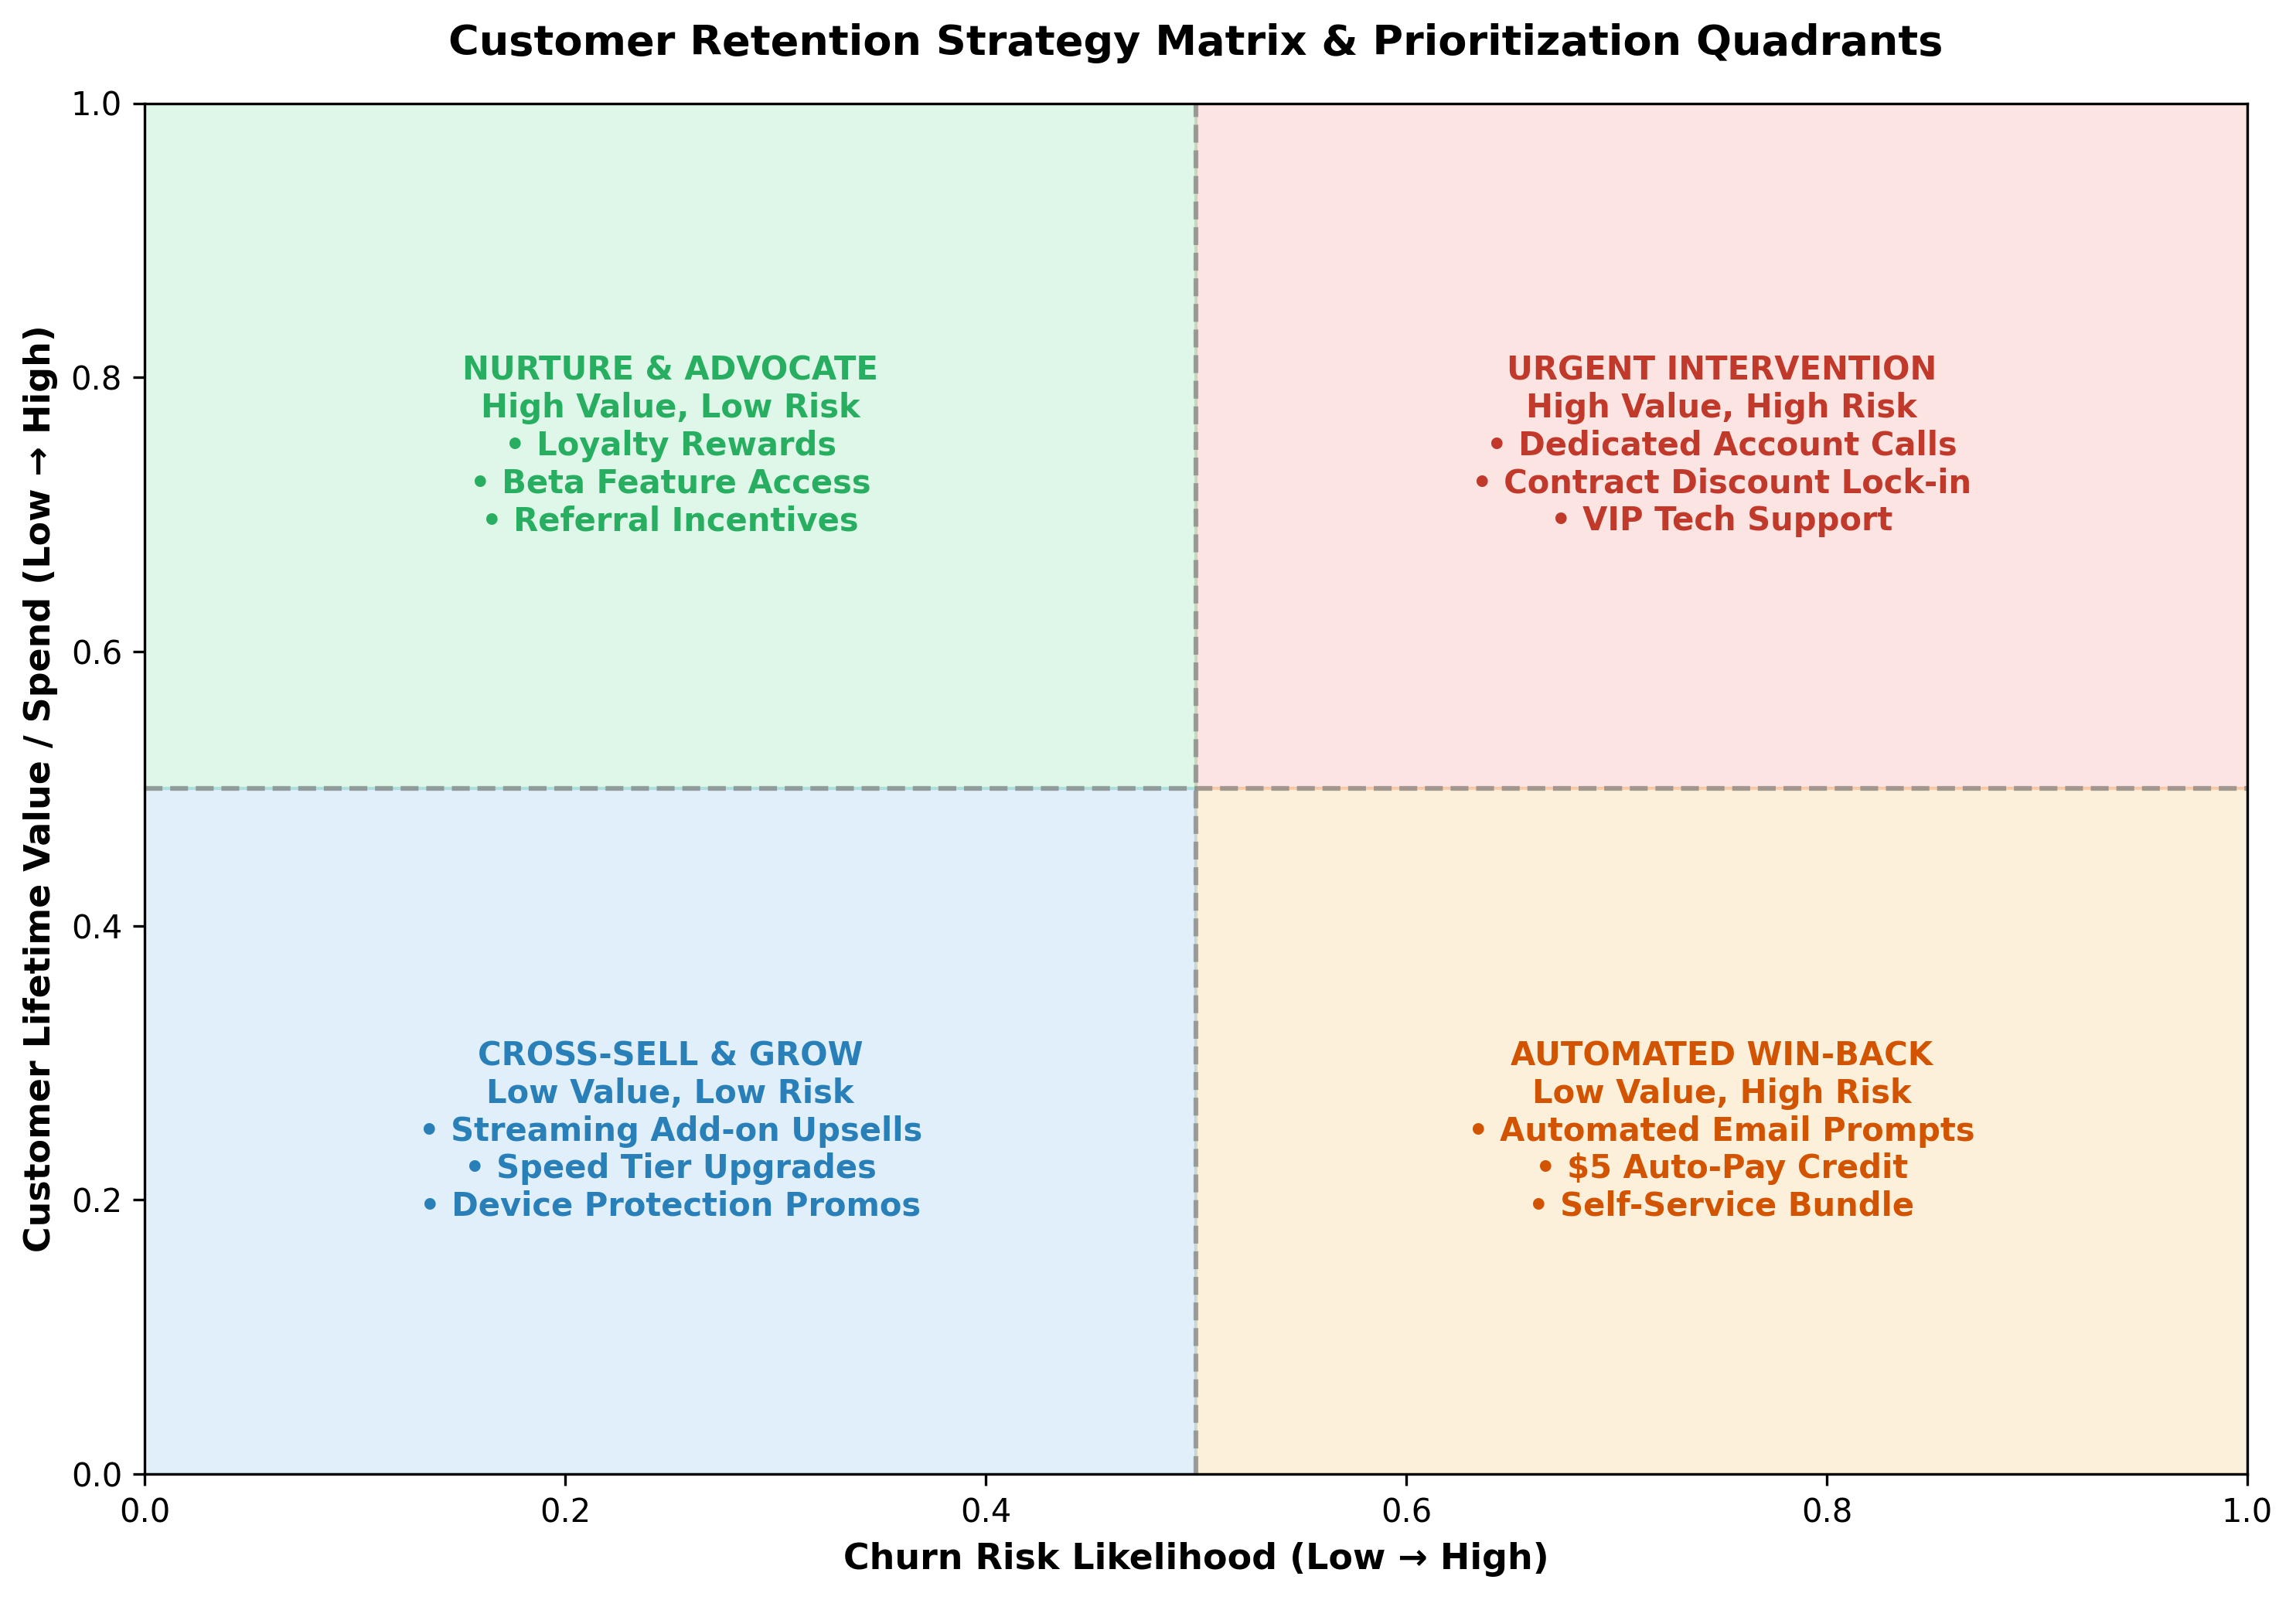

In [3]:
retention_engine.plot_strategy_quadrant()

## 3. Retention Campaign ROI & Financial Simulation

In [4]:
explanations_path = Path("../outputs/customer_level_explanations.csv")
if not explanations_path.exists():
    explanations_path = Path("../../Model Explainability & Retention Strategy/outputs/customer_level_explanations.csv")
if not explanations_path.exists():
    explanations_path = Path("Model Explainability & Retention Strategy/outputs/customer_level_explanations.csv")

customer_explanations = pd.read_csv(explanations_path)
roi_df = retention_engine.simulate_retention_campaign_roi(customer_explanations)
roi_df

,Segment,Customer_Count,Expected_Baseline_Churners,Customers_Saved_By_Campaign,Gross_CLTV_Preserved_USD,Retention_Campaign_Cost_USD,Net_Value_Created_USD,Campaign_ROI_Pct
0,High Risk Cohort (Urgent Proactive),2328,1746.0,558.7,1396800.0,128040.0,1268760.0,990.91
1,Medium Risk Cohort (Nudge & Education),1498,674.1,215.7,539280.0,37450.0,501830.0,1340.00
2,Combined Retention Program (Total),3826,2420.1,774.4,1936080.0,165490.0,1770590.0,1069.91
